# Complete PCA + Clustering Analysis Pipeline

**Purpose:** All-in-one comprehensive analysis from data cleaning to clustering interpretation

**Input:** Country-data.csv

**Output:** Cleaned data, PCA transformation, Clustering results, and 20+ visualizations

**Author:** Data Analysis Pipeline

**Date:** 2026-03-15

## Setup: Import Libraries and Configure

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = os.path.dirname(os.path.abspath('.'))

def out_path(filename: str) -> str:
    """Return an absolute path inside the script directory."""
    return os.path.join(BASE_DIR, filename)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

print("\n" + "="*100)
print("COMPLETE PCA + CLUSTERING ANALYSIS PIPELINE")
print("="*100 + "\n")


COMPLETE PCA + CLUSTERING ANALYSIS PIPELINE



# PHASE 1: DATA CLEANING & EXPLORATION

## Step 1: Load Data

In [2]:
print("\n" + "="*100)
print("PHASE 1: DATA CLEANING & EXPLORATION")
print("="*100 + "\n")

print("STEP 1: LOADING DATA")
print("-"*100)

df = pd.read_csv('Country-data.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Countries: {df.shape[0]}")
print(f"Features: {df.shape[1]}")
print(f"\nFirst 5 rows:")
print(df.head())

country_names = df['country'].values
df_features = df.iloc[:, 1:]


PHASE 1: DATA CLEANING & EXPLORATION

STEP 1: LOADING DATA
----------------------------------------------------------------------------------------------------
Dataset Shape: (167, 10)
Countries: 167
Features: 10

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


## Step 2: Data Quality Check

In [3]:
print("\n\nSTEP 2: DATA QUALITY CHECK")
print("-"*100)

missing_data = df.isnull().sum()
print(f"Missing values per column:\n{missing_data}")

if missing_data.sum() > 0:
    print(f"\n⚠️  Removing {len(df) - len(df.dropna())} rows with missing values")
    df = df.dropna()
    country_names = df['country'].values
    df_features = df.iloc[:, 1:]

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    country_names = df['country'].values
    df_features = df.iloc[:, 1:]

print(f"\n✅ Final dataset: {df.shape[0]} countries × {df.shape[1]-1} features")



STEP 2: DATA QUALITY CHECK
----------------------------------------------------------------------------------------------------
Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Duplicate rows: 0

✅ Final dataset: 167 countries × 9 features


## Step 3: Descriptive Statistics

In [4]:
print("\n\nSTEP 3: DESCRIPTIVE STATISTICS")
print("-"*100)
print(df_features.describe())



STEP 3: DESCRIPTIVE STATISTICS
----------------------------------------------------------------------------------------------------
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.51384

## Step 4: Outlier Detection (IQR Method)

In [5]:
print("\n\nSTEP 4: OUTLIER DETECTION (IQR Method)")
print("-"*100)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outlier_summary = {}
for col in df_features.columns:
    outliers = detect_outliers_iqr(df, col)
    outlier_summary[col] = len(outliers)

print(f"Outliers per column: {outlier_summary}")
print(f"Total outlier instances: {sum(outlier_summary.values())}")



STEP 4: OUTLIER DETECTION (IQR Method)
----------------------------------------------------------------------------------------------------
Outliers per column: {'child_mort': 4, 'exports': 5, 'health': 2, 'imports': 4, 'income': 8, 'inflation': 5, 'life_expec': 3, 'total_fer': 1, 'gdpp': 25}
Total outlier instances: 57


## Step 5: Correlation Analysis

In [6]:
print("\n\nSTEP 5: CORRELATION ANALYSIS")
print("-"*100)
correlation_matrix = df_features.corr()
print("\nHighly Correlated Features (|r| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"  {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")



STEP 5: CORRELATION ANALYSIS
----------------------------------------------------------------------------------------------------

Highly Correlated Features (|r| > 0.7):
  child_mort ↔ life_expec: -0.887
  child_mort ↔ total_fer: 0.848
  exports ↔ imports: 0.737
  income ↔ gdpp: 0.896
  life_expec ↔ total_fer: -0.761


## Step 6: Feature Range Analysis

In [7]:
print("\n\nSTEP 6: FEATURE RANGE ANALYSIS")
print("-"*100)
print(f"\n{'Feature':<20} {'Min':<15} {'Max':<15} {'Range':<15}")
print("-"*65)
for col in df_features.columns:
    feature_range = df_features[col].max() - df_features[col].min()
    print(f"{col:<20} {df_features[col].min():>13.2f}  {df_features[col].max():>13.2f}  {feature_range:>13.2f}")

# Save cleaned data
df.to_csv('country_data_cleaned.csv', index=False)
print("\n✅ Saved: country_data_cleaned.csv")



STEP 6: FEATURE RANGE ANALYSIS
----------------------------------------------------------------------------------------------------

Feature              Min             Max             Range          
-----------------------------------------------------------------
child_mort                    2.60         208.00         205.40
exports                       0.11         200.00         199.89
health                        1.81          17.90          16.09
imports                       0.07         174.00         173.93
income                      609.00      125000.00      124391.00
inflation                    -4.21         104.00         108.21
life_expec                   32.10          82.80          50.70
total_fer                     1.15           7.49           6.34
gdpp                        231.00      105000.00      104769.00

✅ Saved: country_data_cleaned.csv


## Phase 1 Visualizations: Distribution & Outliers



CREATING VISUALIZATIONS - PHASE 1...
----------------------------------------------------------------------------------------------------
✅ Saved: 01_distributions.png


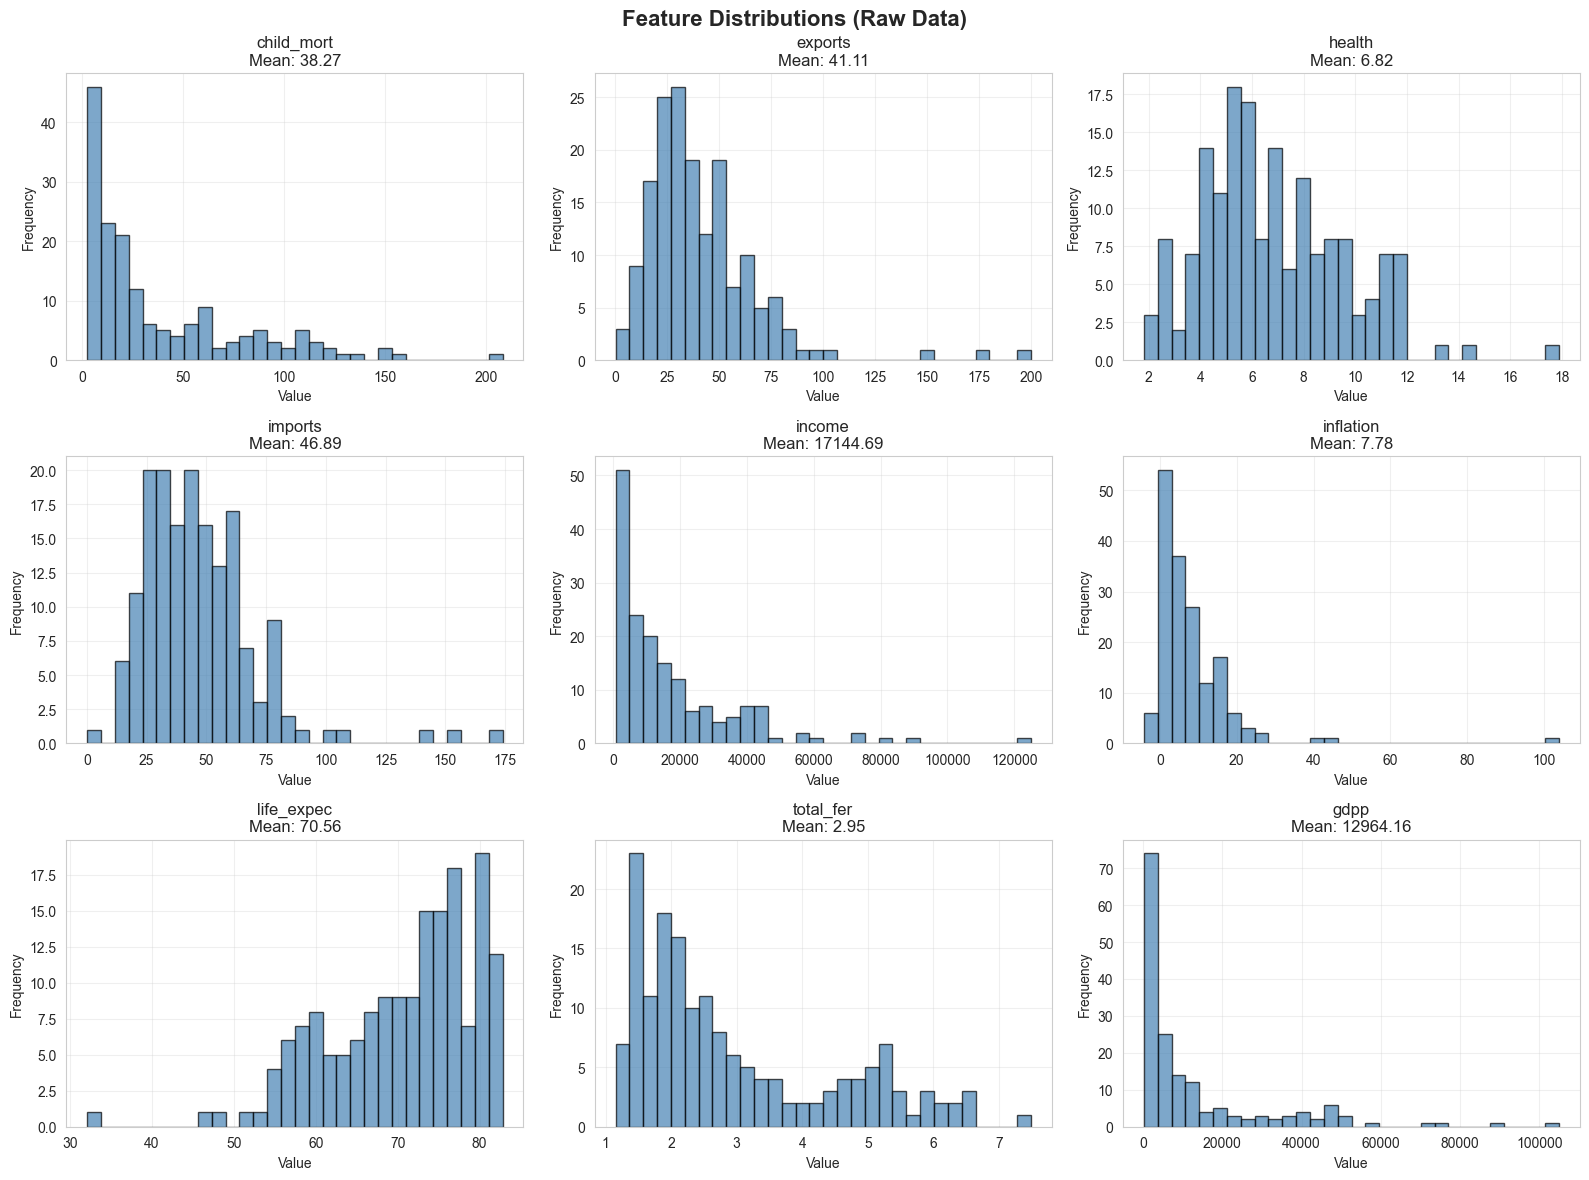

In [8]:
print("\n\nCREATING VISUALIZATIONS - PHASE 1...")
print("-"*100)

# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature Distributions (Raw Data)', fontsize=16, fontweight='bold')

for idx, col in enumerate(df_features.columns):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df_features[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}\nMean: {df_features[col].mean():.2f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_distributions.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 01_distributions.png")
plt.show()

✅ Saved: 02_boxplots_outliers.png


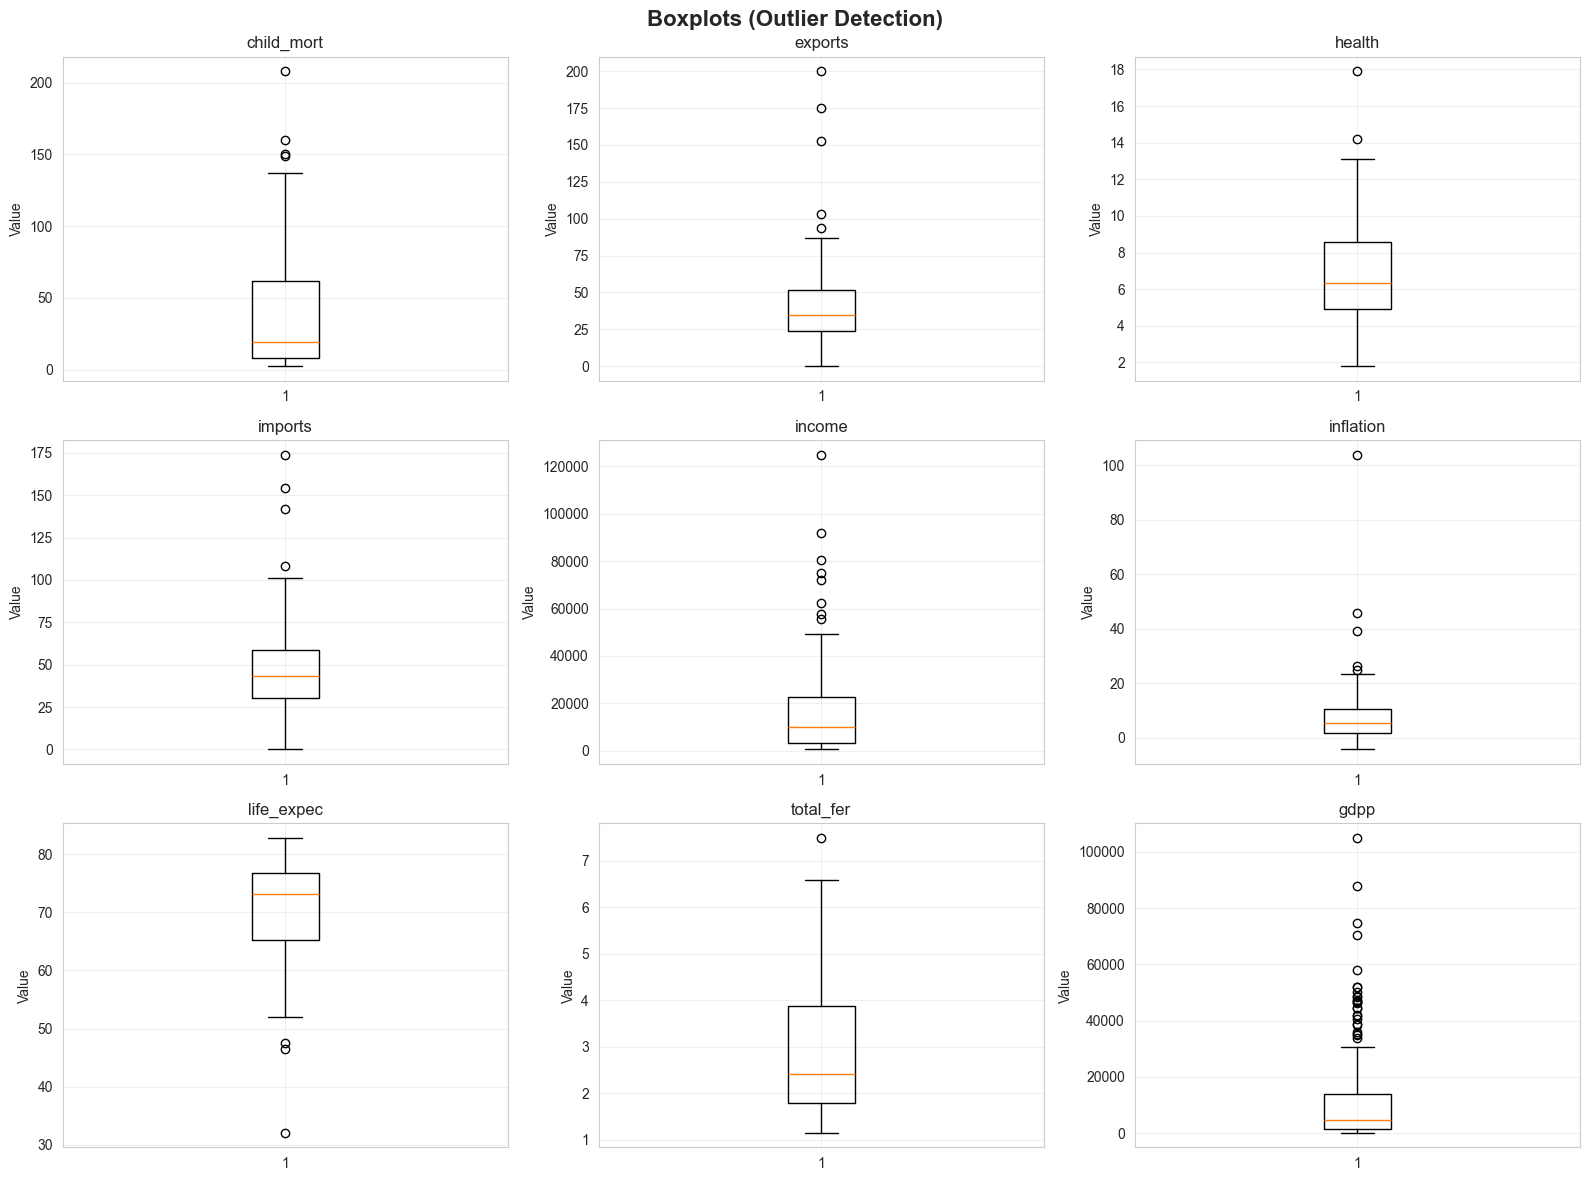

In [9]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Boxplots (Outlier Detection)', fontsize=16, fontweight='bold')

for idx, col in enumerate(df_features.columns):
    ax = axes[idx // 3, idx % 3]
    ax.boxplot(df_features[col], vert=True)
    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_boxplots_outliers.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 02_boxplots_outliers.png")
plt.show()

✅ Saved: 03_correlation_heatmap.png


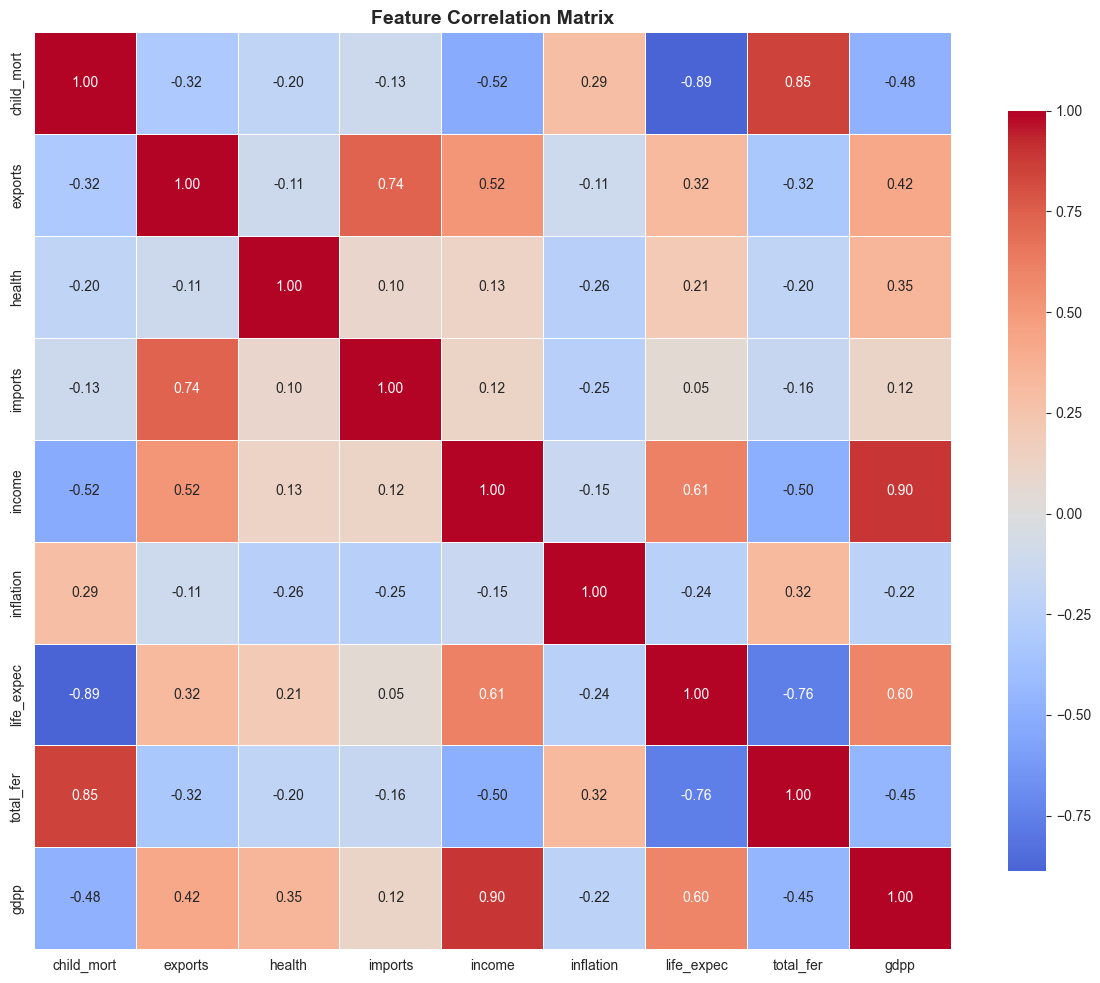

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 03_correlation_heatmap.png")
plt.show()

✅ Saved: 04_pairplot.png


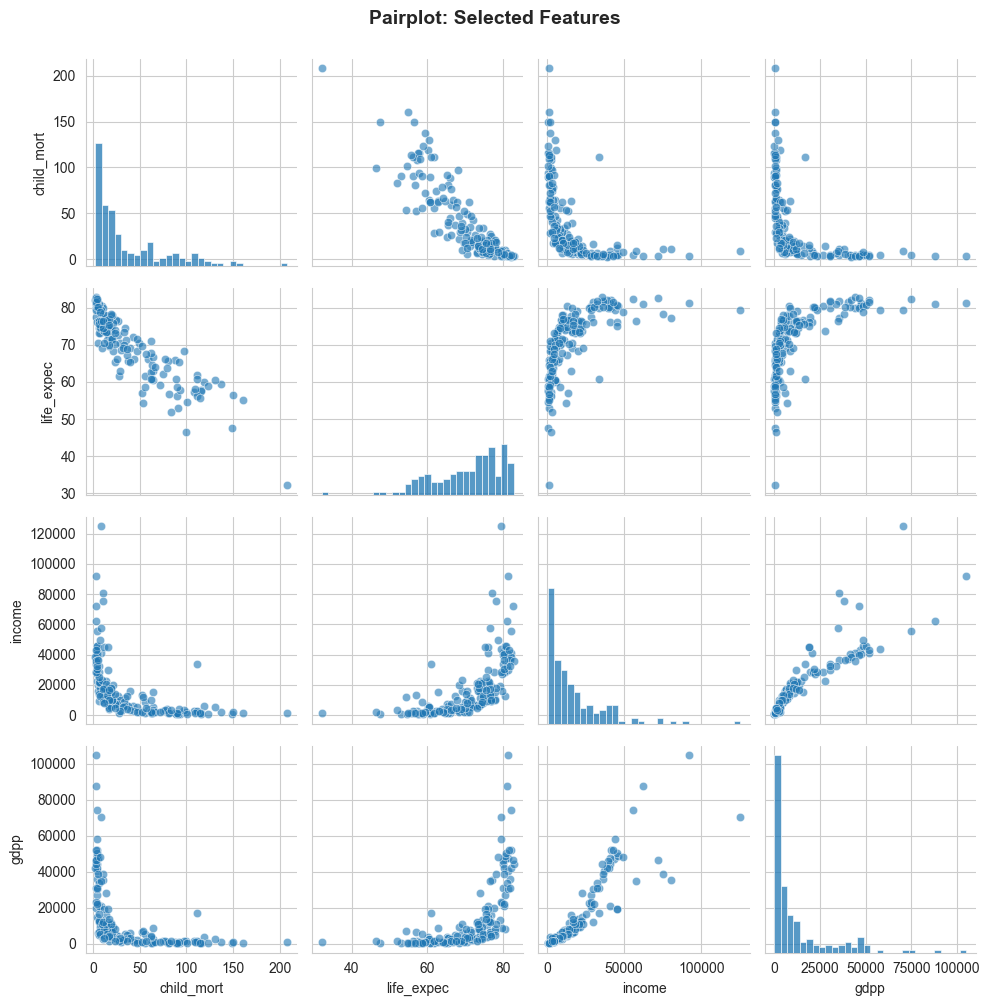

In [11]:
# Pairplot
selected_features = ['child_mort', 'life_expec', 'income', 'gdpp']
pairplot_data = df[selected_features]
fig = sns.pairplot(pairplot_data, diag_kind='hist', plot_kws={'alpha': 0.6}, diag_kws={'bins': 30})
fig.fig.suptitle('Pairplot: Selected Features', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('04_pairplot.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 04_pairplot.png")
plt.show()

✅ Saved: 05_feature_ranges.png


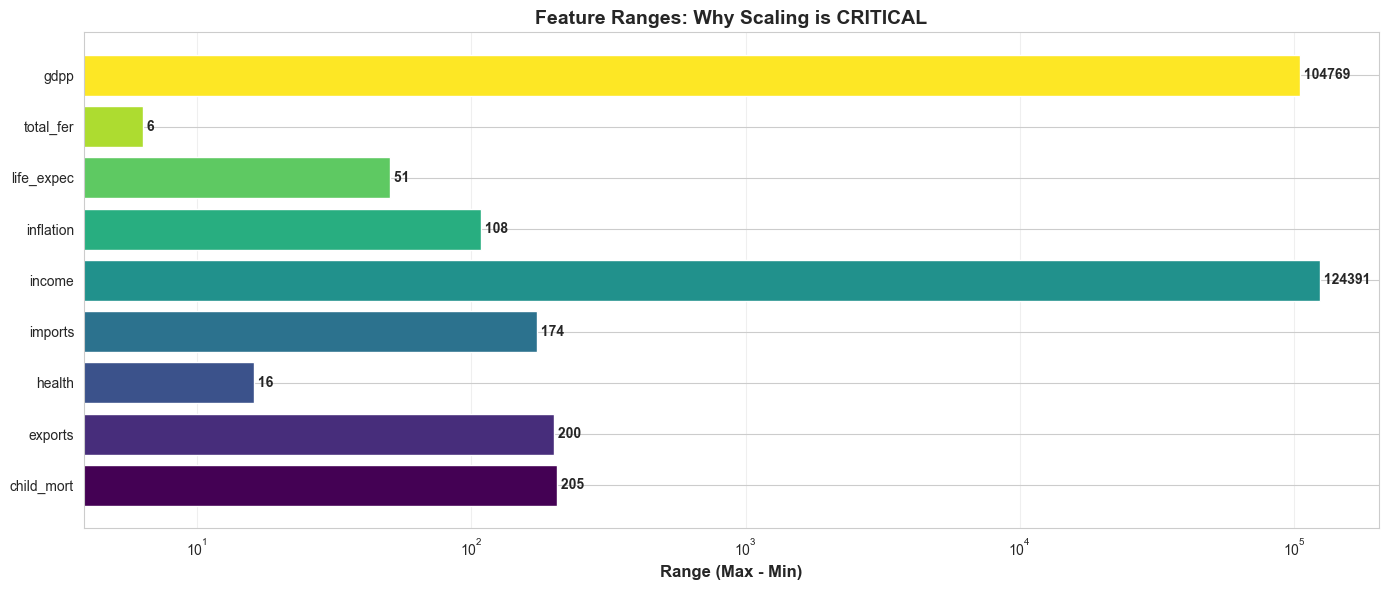

In [12]:
# Feature ranges
fig, ax = plt.subplots(figsize=(14, 6))
feature_ranges = df_features.max() - df_features.min()
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_ranges)))
bars = ax.barh(range(len(feature_ranges)), feature_ranges, color=colors)
ax.set_yticks(range(len(feature_ranges)))
ax.set_yticklabels(feature_ranges.index)
ax.set_xlabel('Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_title('Feature Ranges: Why Scaling is CRITICAL', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3, axis='x')

for idx, (bar, val) in enumerate(zip(bars, feature_ranges)):
    ax.text(val, idx, f' {val:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('05_feature_ranges.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 05_feature_ranges.png")
plt.show()

---

# PHASE 2: PCA IMPLEMENTATION

## Step 1: Feature Standardization

In [13]:
print("\n\n" + "="*100)
print("PHASE 2: PCA IMPLEMENTATION")
print("="*100 + "\n")

print("STEP 1: FEATURE STANDARDIZATION")
print("-"*100)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(df_scaled, columns=df_features.columns)

print("Before Standardization - Mean & StdDev:")
print(f"  Mean: {df_features.mean().mean():.2f}")
print(f"  StdDev: {df_features.std().mean():.2f}")

print("\nAfter Standardization - Mean & StdDev:")
print(f"  Mean: {df_scaled.mean().mean():.6f}")
print(f"  StdDev: {df_scaled.std().mean():.2f}")
print("✅ Standardization complete")



PHASE 2: PCA IMPLEMENTATION

STEP 1: FEATURE STANDARDIZATION
----------------------------------------------------------------------------------------------------
Before Standardization - Mean & StdDev:
  Mean: 3369.25
  StdDev: 4191.38

After Standardization - Mean & StdDev:
  Mean: 0.000000
  StdDev: 1.00
✅ Standardization complete


## Step 2: Fit Full PCA Model

In [14]:
print("\n\nSTEP 2: FITTING FULL PCA MODEL")
print("-"*100)

n_components = df_scaled.shape[1]
pca_full = PCA(n_components=n_components)
pca_transformed_full = pca_full.fit_transform(df_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
eigenvalues = pca_full.explained_variance_

print(f"\nPCA fitted with {n_components} components")
print(f"\n{'Component':<12} {'Eigenvalue':<15} {'Variance %':<15} {'Cumulative %':<15}")
print("-"*60)
for i in range(n_components):
    print(f"PC{i+1:<10} {eigenvalues[i]:>13.4f} {explained_variance[i]*100:>13.2f}% {cumulative_variance[i]*100:>13.2f}%")



STEP 2: FITTING FULL PCA MODEL
----------------------------------------------------------------------------------------------------

PCA fitted with 9 components

Component    Eigenvalue      Variance %      Cumulative %   
------------------------------------------------------------
PC1                 4.1606         45.95%         45.95%
PC2                 1.5557         17.18%         63.13%
PC3                 1.1774         13.00%         76.14%
PC4                 1.0008         11.05%         87.19%
PC5                 0.6646          7.34%         94.53%
PC6                 0.2249          2.48%         97.02%
PC7                 0.1141          1.26%         98.28%
PC8                 0.0888          0.98%         99.26%
PC9                 0.0673          0.74%        100.00%


## Step 3: Determine Optimal Components

In [15]:
print("\n\nSTEP 3: DETERMINING OPTIMAL COMPONENTS")
print("-"*100)

variance_threshold = 0.95
n_components_optimal = np.argmax(cumulative_variance >= variance_threshold) + 1
n_components_optimal = min(n_components_optimal, 5)

print(f"Components needed for 95% variance: {n_components_optimal}")
print(f"Variance explained: {cumulative_variance[n_components_optimal-1]*100:.2f}%")



STEP 3: DETERMINING OPTIMAL COMPONENTS
----------------------------------------------------------------------------------------------------
Components needed for 95% variance: 5
Variance explained: 94.53%


## Step 4: Fit Optimal PCA Model

In [16]:
print("\n\nSTEP 4: FITTING OPTIMAL PCA MODEL")
print("-"*100)

pca = PCA(n_components=n_components_optimal)
pca_transformed = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(
    pca_transformed,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)]
)
pca_df['country'] = country_names

loadings = pca.components_
loadings_df = pd.DataFrame(
    loadings.T,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)],
    index=df_features.columns
)

print(f"✅ Fitted PCA with {n_components_optimal} optimal components")
print(f"   Dimensionality reduction: {df_scaled.shape[1]} → {n_components_optimal} ({(1-n_components_optimal/df_scaled.shape[1])*100:.1f}% reduction)")



STEP 4: FITTING OPTIMAL PCA MODEL
----------------------------------------------------------------------------------------------------
✅ Fitted PCA with 5 optimal components
   Dimensionality reduction: 9 → 5 (44.4% reduction)


## Step 5: Component Interpretation

In [17]:
print("\n\nSTEP 5: COMPONENT INTERPRETATION")
print("-"*100)

for pc_idx in range(n_components_optimal):
    pc_name = f'PC{pc_idx+1}'
    pc_loading = loadings_df[pc_name]
    top_pos = pc_loading.nlargest(3)
    top_neg = pc_loading.nsmallest(3)
    
    print(f"\n{pc_name}: ({explained_variance[pc_idx]*100:.2f}% variance)")
    print(f"  Positive contributors:")
    for feat, val in top_pos.items():
        print(f"    ✓ {feat:20s}: {val:+.3f}")
    print(f"  Negative contributors:")
    for feat, val in top_neg.items():
        print(f"    ✗ {feat:20s}: {val:+.3f}")

# Save PCA results
pca_df.to_csv('pca_transformed_data.csv', index=False)
loadings_df.to_csv('pca_loadings.csv')
print("\n✅ Saved: pca_transformed_data.csv")
print("✅ Saved: pca_loadings.csv")



STEP 5: COMPONENT INTERPRETATION
----------------------------------------------------------------------------------------------------

PC1: (45.95% variance)
  Positive contributors:
    ✓ life_expec          : +0.426
    ✓ income              : +0.398
    ✓ gdpp                : +0.393
  Negative contributors:
    ✗ child_mort          : -0.420
    ✗ total_fer           : -0.404
    ✗ inflation           : -0.193

PC2: (17.18% variance)
  Positive contributors:
    ✓ imports             : +0.672
    ✓ exports             : +0.613
    ✓ child_mort          : +0.193
  Negative contributors:
    ✗ health              : -0.243
    ✗ life_expec          : -0.223
    ✗ gdpp                : -0.046

PC3: (13.00% variance)
  Positive contributors:
    ✓ inflation           : +0.643
    ✓ income              : +0.302
    ✓ exports             : +0.145
  Negative contributors:
    ✗ health              : -0.597
    ✗ imports             : -0.300
    ✗ child_mort          : -0.030

PC4: (11.05

## Phase 2 Visualizations: PCA Variance Analysis



CREATING VISUALIZATIONS - PHASE 2...
----------------------------------------------------------------------------------------------------
✅ Saved: 06_pca_variance_analysis.png


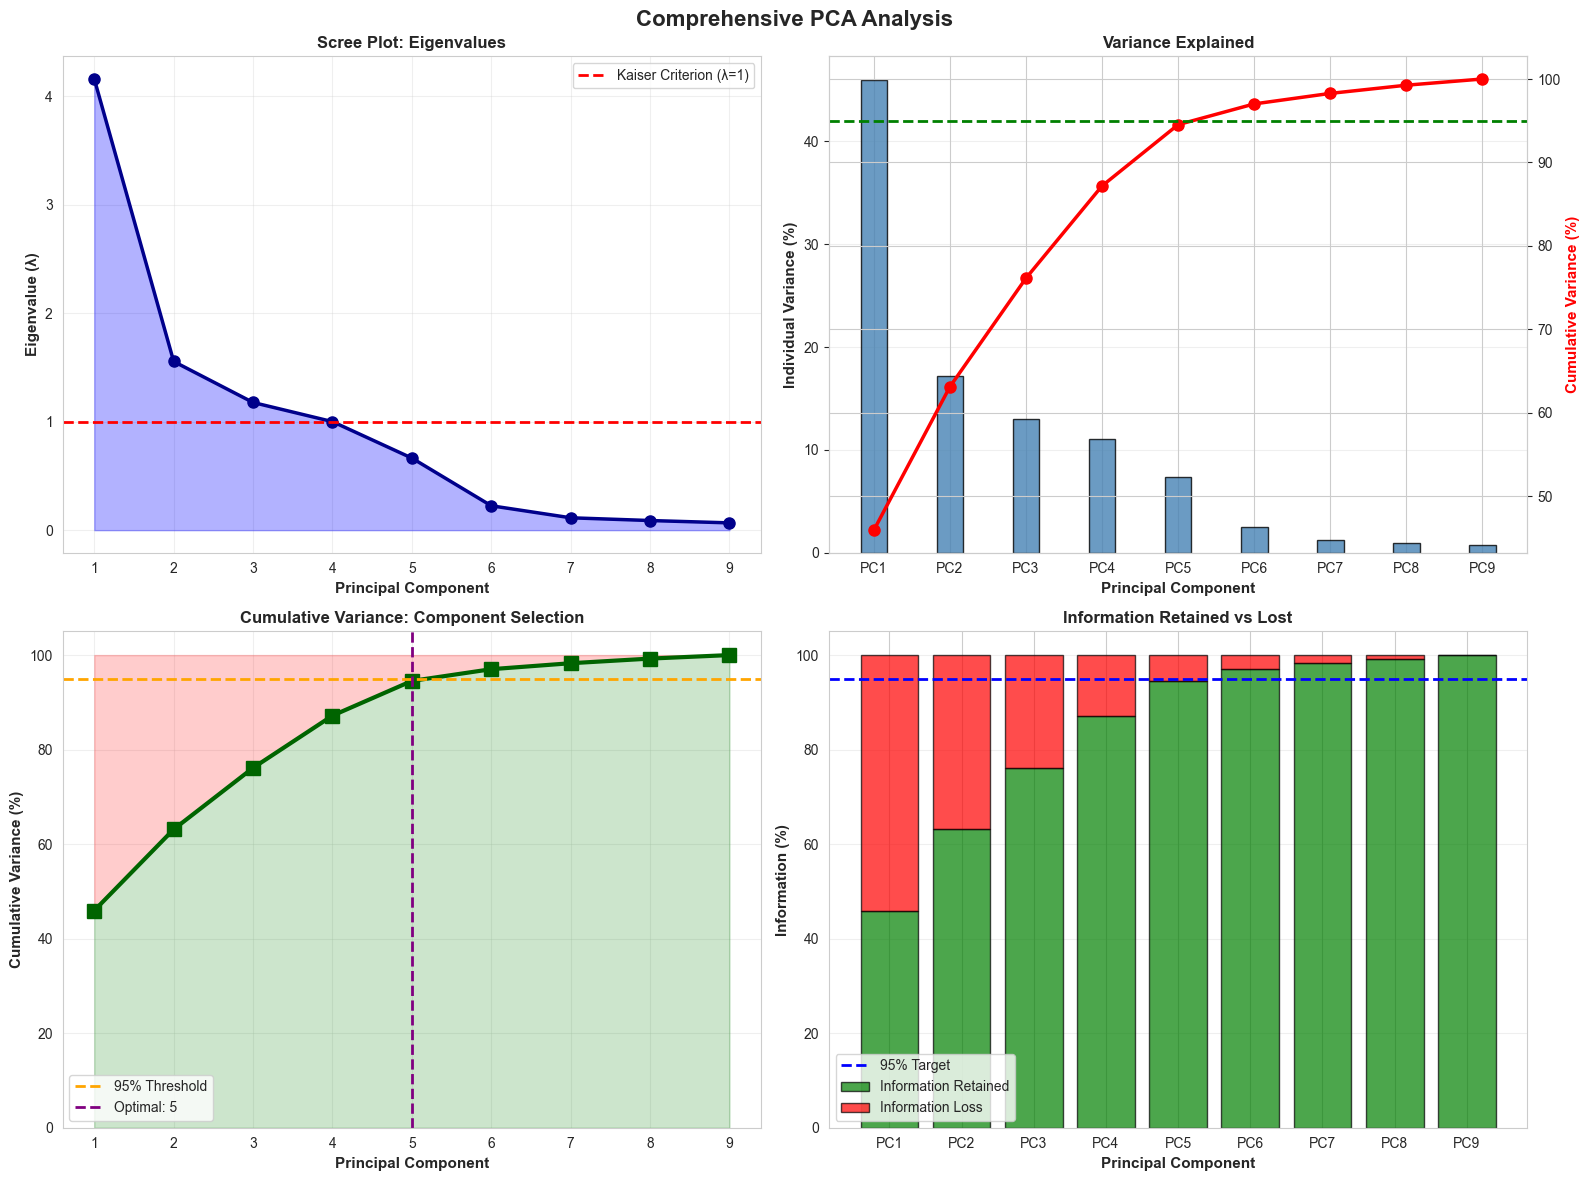

In [18]:
print("\n\nCREATING VISUALIZATIONS - PHASE 2...")
print("-"*100)

# Variance analysis plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comprehensive PCA Analysis', fontsize=16, fontweight='bold')

# Scree plot
ax = axes[0, 0]
ax.plot(range(1, n_components+1), eigenvalues, 'o-', color='darkblue', 
        linewidth=2.5, markersize=8)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Kaiser Criterion (λ=1)')
ax.fill_between(range(1, n_components+1), eigenvalues, alpha=0.3, color='blue')
ax.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Eigenvalue (λ)', fontsize=11, fontweight='bold')
ax.set_title('Scree Plot: Eigenvalues', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Variance explained
ax = axes[0, 1]
width = 0.35
x_pos = np.arange(n_components)
ax.bar(x_pos, explained_variance*100, width, label='Individual', 
       alpha=0.8, color='steelblue', edgecolor='black')
ax2 = ax.twinx()
ax2.plot(x_pos, cumulative_variance*100, 'ro-', linewidth=2.5, markersize=8, label='Cumulative')
ax2.axhline(y=95, color='green', linestyle='--', linewidth=2, label='95% Threshold')
ax2.set_ylabel('Cumulative Variance (%)', fontsize=11, fontweight='bold', color='red')
ax.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Individual Variance (%)', fontsize=11, fontweight='bold')
ax.set_title('Variance Explained', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'PC{i+1}' for i in range(n_components)])
ax.grid(True, alpha=0.3, axis='y')

# Cumulative variance
ax = axes[1, 0]
ax.plot(range(1, n_components+1), cumulative_variance*100, 's-', color='darkgreen', 
        linewidth=3, markersize=10)
ax.fill_between(range(1, n_components+1), 0, cumulative_variance*100, alpha=0.2, color='green')
ax.fill_between(range(1, n_components+1), cumulative_variance*100, 100, alpha=0.2, color='red')
ax.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Threshold')
ax.axvline(x=n_components_optimal, color='purple', linestyle='--', linewidth=2, 
           label=f'Optimal: {n_components_optimal}')
ax.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Variance (%)', fontsize=11, fontweight='bold')
ax.set_title('Cumulative Variance: Component Selection', fontsize=12, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)
ax.legend()

# Information retention
ax = axes[1, 1]
information_retained = cumulative_variance * 100
information_loss = 100 - information_retained
x_pos = np.arange(n_components)
ax.bar(x_pos, information_retained, label='Information Retained', 
       color='green', alpha=0.7, edgecolor='black')
ax.bar(x_pos, information_loss, bottom=information_retained, label='Information Loss', 
       color='red', alpha=0.7, edgecolor='black')
ax.axhline(y=95, color='blue', linestyle='--', linewidth=2, label='95% Target')
ax.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Information (%)', fontsize=11, fontweight='bold')
ax.set_title('Information Retained vs Lost', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'PC{i+1}' for i in range(n_components)])
ax.set_ylim([0, 105])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('06_pca_variance_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 06_pca_variance_analysis.png")
plt.show()

## PCA Loadings Analysis

✅ Saved: 07_pca_loadings_heatmap.png


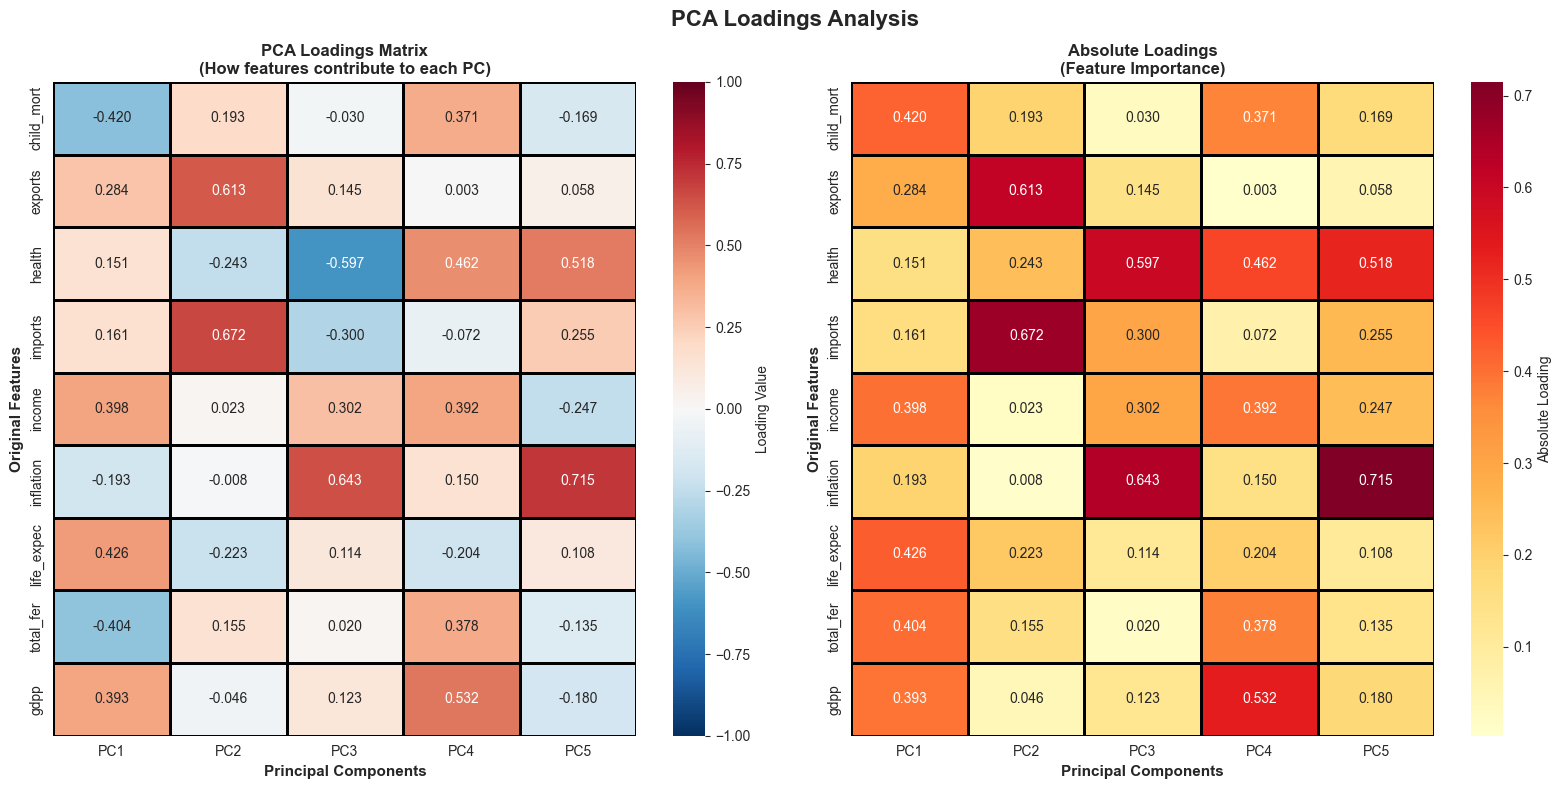

In [19]:
# Loadings heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('PCA Loadings Analysis', fontsize=16, fontweight='bold')

ax = axes[0]
sns.heatmap(loadings_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Loading Value'}, ax=ax, linewidths=1, 
            linecolor='black', vmin=-1, vmax=1)
ax.set_title('PCA Loadings Matrix\n(How features contribute to each PC)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Principal Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Original Features', fontsize=11, fontweight='bold')

ax = axes[1]
loadings_abs = np.abs(loadings_df)
sns.heatmap(loadings_abs, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Absolute Loading'}, ax=ax, linewidths=1, linecolor='black')
ax.set_title('Absolute Loadings\n(Feature Importance)', fontsize=12, fontweight='bold')
ax.set_xlabel('Principal Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Original Features', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('07_pca_loadings_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 07_pca_loadings_heatmap.png")
plt.show()

✅ Saved: 08_pca_loadings_bars.png


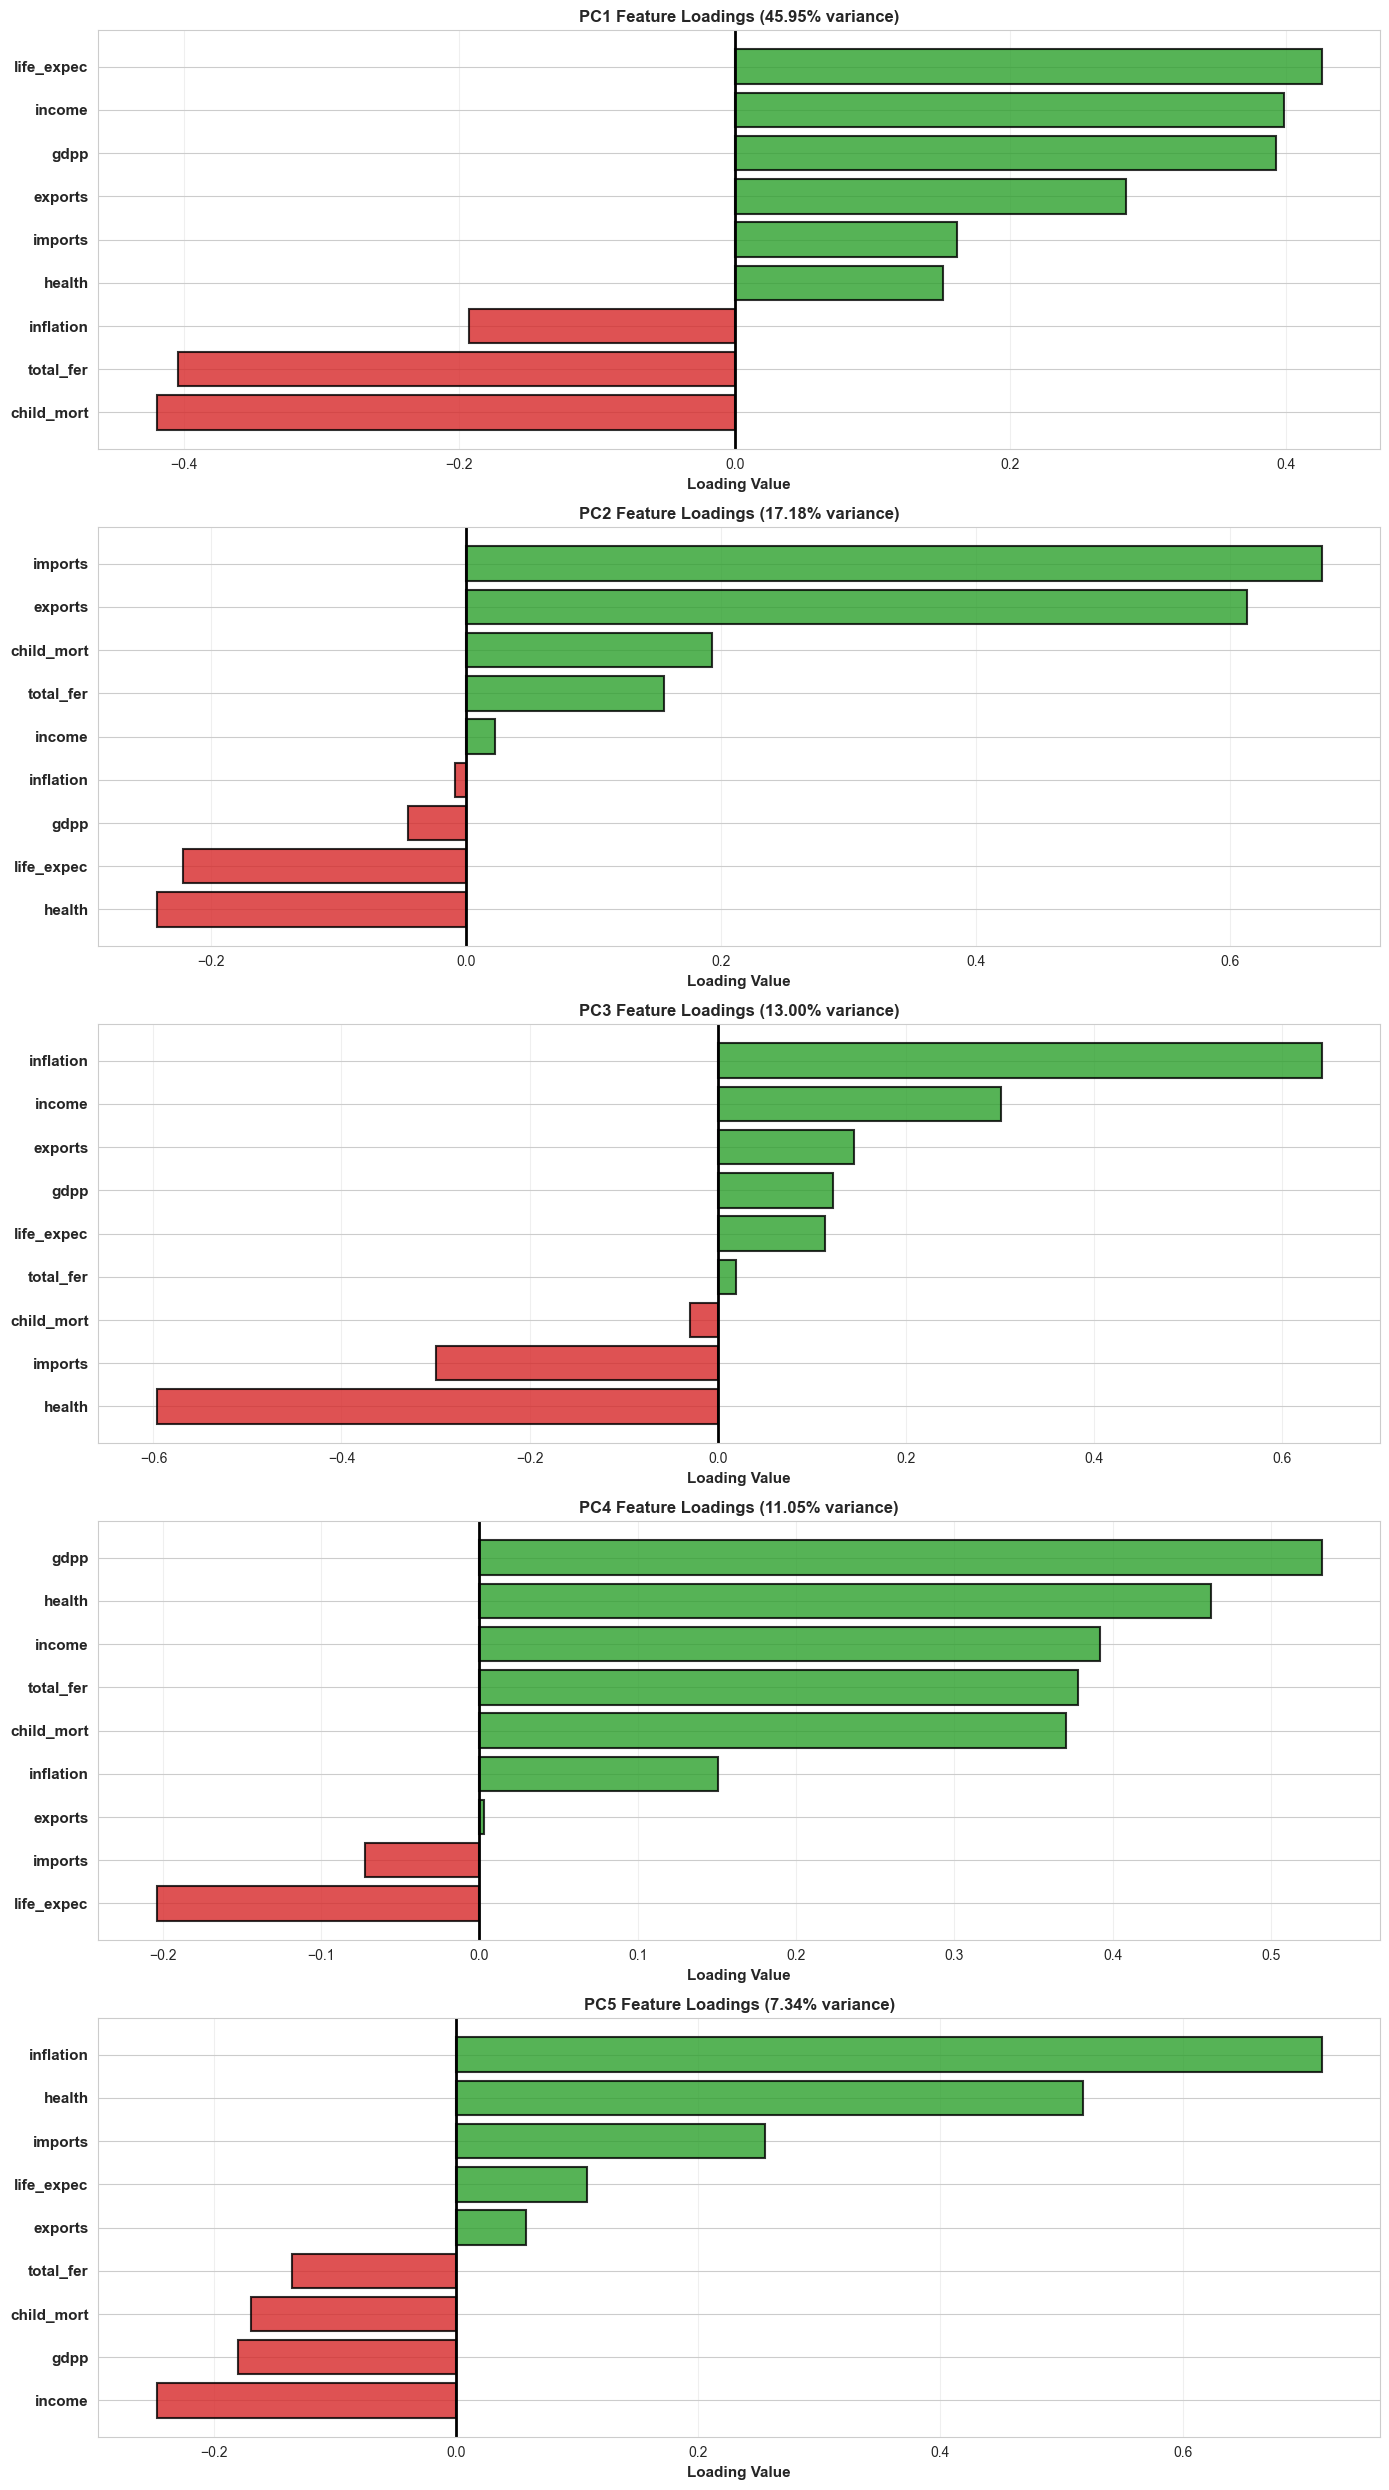

In [20]:
# Loadings bar charts
fig, axes = plt.subplots(n_components_optimal, 1, figsize=(14, 5*n_components_optimal))
if n_components_optimal == 1:
    axes = [axes]

for pc_idx in range(n_components_optimal):
    ax = axes[pc_idx]
    pc_loadings = loadings_df[f'PC{pc_idx+1}'].sort_values(ascending=True)
    colors = ['#d62728' if x < 0 else '#2ca02c' for x in pc_loadings.values]
    
    bars = ax.barh(range(len(pc_loadings)), pc_loadings.values, 
                   color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.set_yticks(range(len(pc_loadings)))
    ax.set_yticklabels(pc_loadings.index, fontsize=11, fontweight='bold')
    ax.set_xlabel('Loading Value', fontsize=11, fontweight='bold')
    ax.set_title(f'PC{pc_idx+1} Feature Loadings ({explained_variance[pc_idx]*100:.2f}% variance)',
                fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=2)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('08_pca_loadings_bars.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 08_pca_loadings_bars.png")
plt.show()

## PCA Biplots

✅ Saved: 09_biplot_pc1_pc2.png


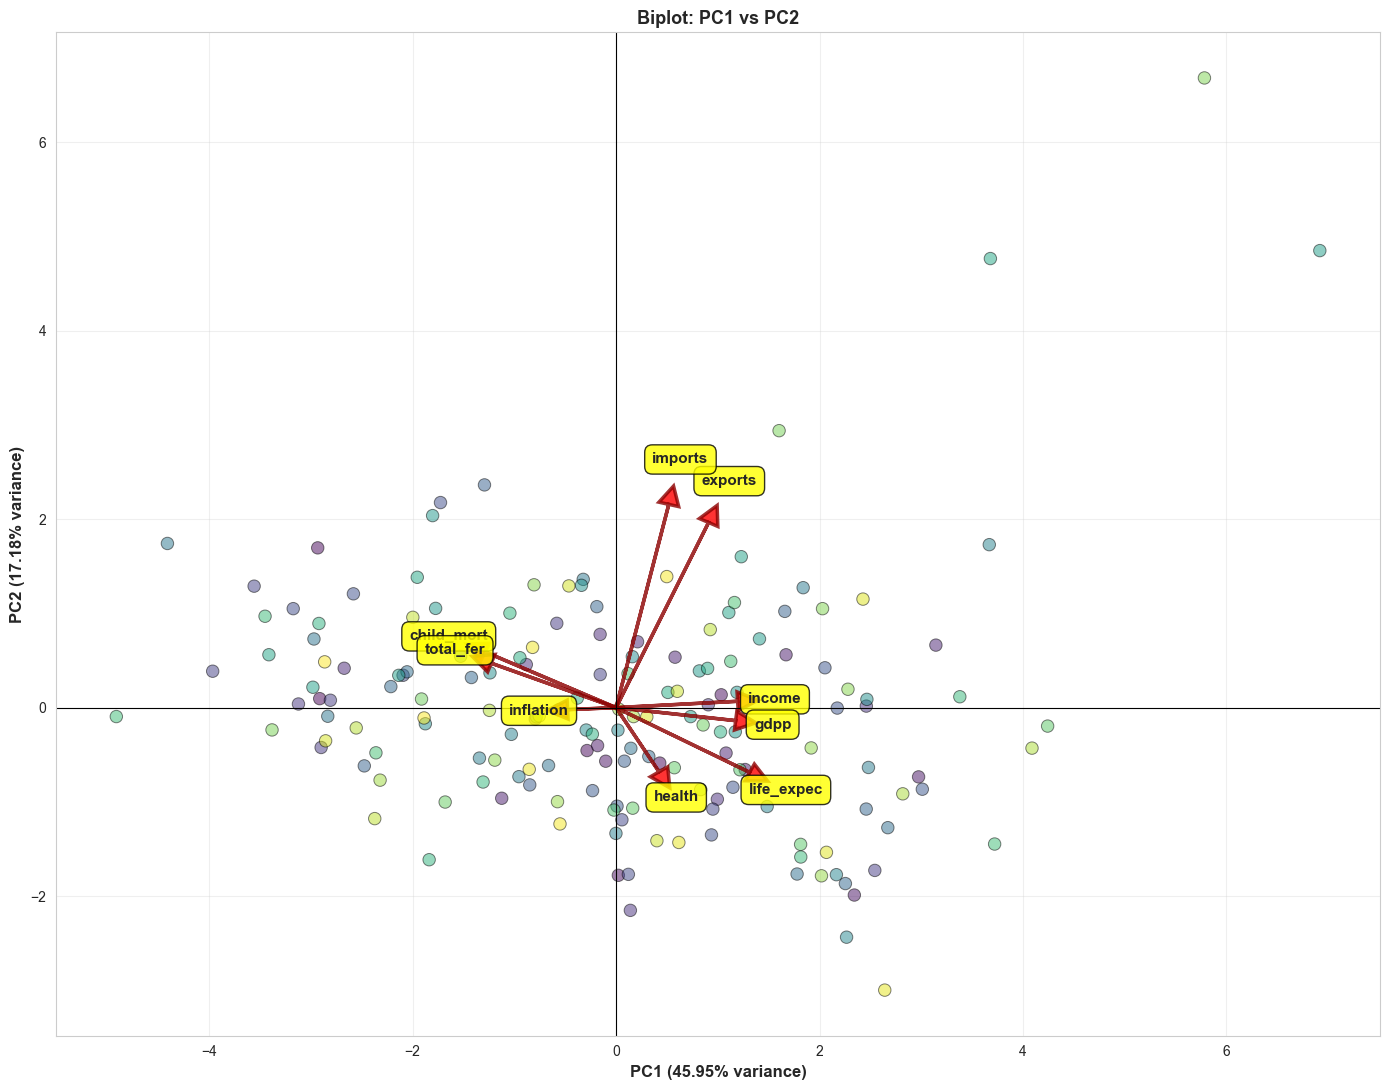

In [21]:
# Biplot PC1 vs PC2
if n_components_optimal >= 2:
    fig, ax = plt.subplots(figsize=(14, 11))
    
    scatter = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 1],
                        alpha=0.5, s=80, c=range(len(country_names)),
                        cmap='viridis', edgecolors='black', linewidth=0.7)
    
    scale = 3.5
    for i, feature in enumerate(df_features.columns):
        ax.arrow(0, 0, loadings[0, i]*scale, loadings[1, i]*scale,
                head_width=0.2, head_length=0.2, fc='red', ec='darkred',
                alpha=0.8, linewidth=2.5, length_includes_head=True)
        
        ax.text(loadings[0, i]*scale*1.12, loadings[1, i]*scale*1.12,
               feature, fontsize=11, fontweight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black'))
    
    ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.2f}% variance)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.2f}% variance)', 
                 fontsize=12, fontweight='bold')
    ax.set_title('Biplot: PC1 vs PC2', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=0, color='black', linewidth=0.8)
    
    plt.tight_layout()
    plt.savefig('09_biplot_pc1_pc2.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: 09_biplot_pc1_pc2.png")
    plt.show()

✅ Saved: 10_biplot_pc1_pc3.png


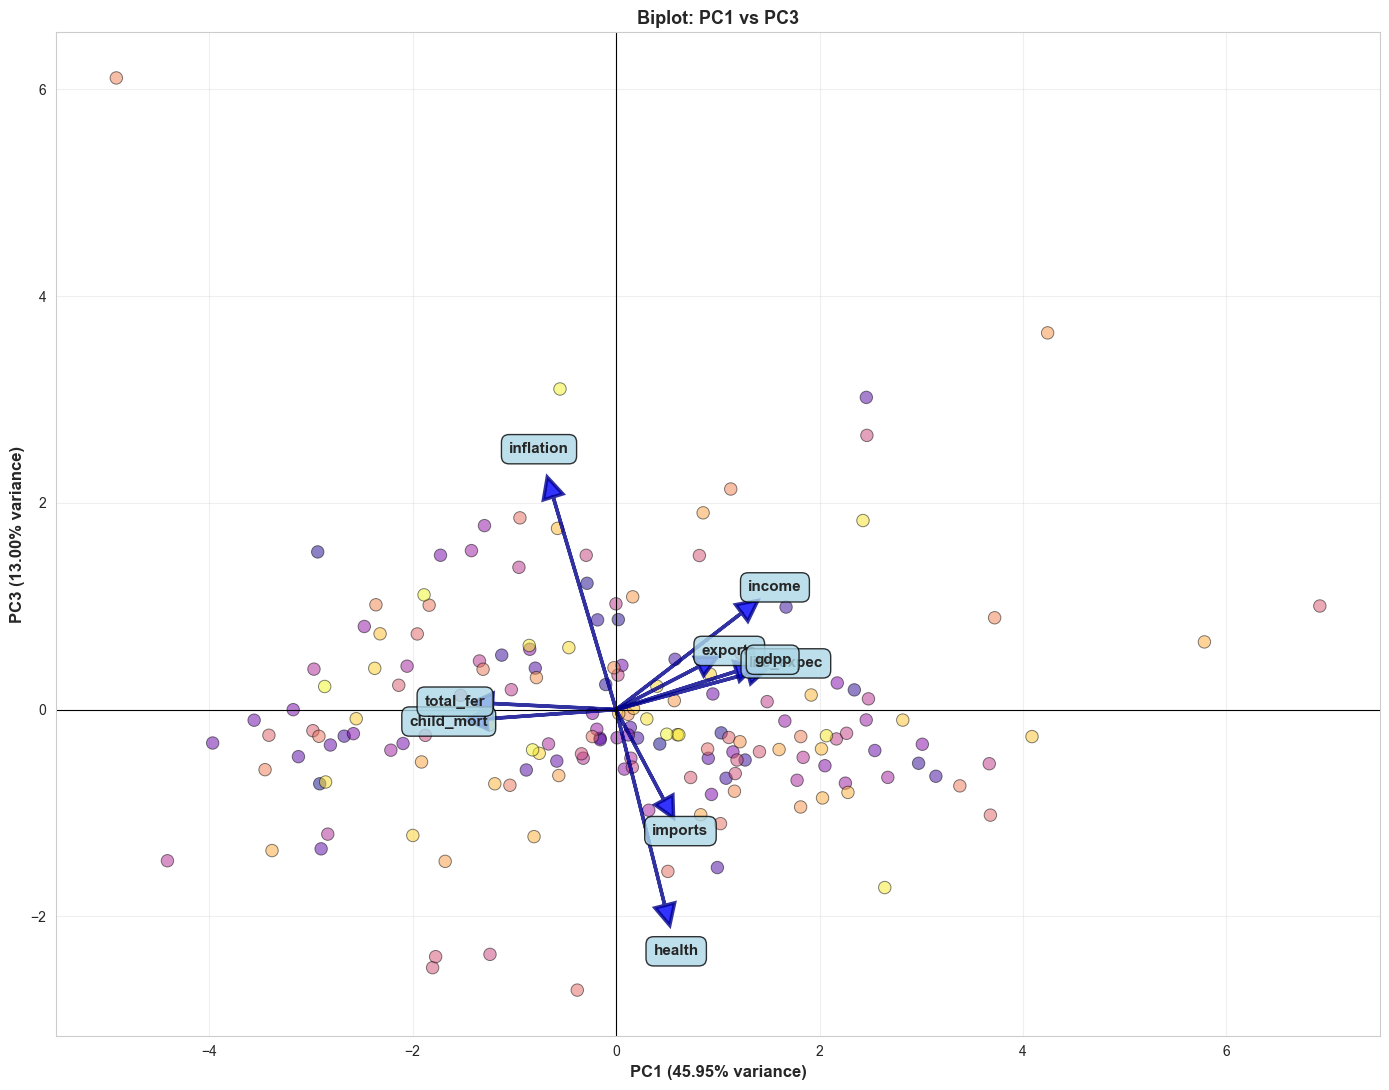

In [22]:
# Biplot PC1 vs PC3
if n_components_optimal >= 3:
    fig, ax = plt.subplots(figsize=(14, 11))
    
    scatter = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 2],
                        alpha=0.5, s=80, c=range(len(country_names)),
                        cmap='plasma', edgecolors='black', linewidth=0.7)
    
    scale = 3.5
    for i, feature in enumerate(df_features.columns):
        ax.arrow(0, 0, loadings[0, i]*scale, loadings[2, i]*scale,
                head_width=0.2, head_length=0.2, fc='blue', ec='darkblue',
                alpha=0.8, linewidth=2.5, length_includes_head=True)
        
        ax.text(loadings[0, i]*scale*1.12, loadings[2, i]*scale*1.12,
               feature, fontsize=11, fontweight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8, edgecolor='black'))
    
    ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.2f}% variance)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PC3 ({explained_variance[2]*100:.2f}% variance)', 
                 fontsize=12, fontweight='bold')
    ax.set_title('Biplot: PC1 vs PC3', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('10_biplot_pc1_pc3.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: 10_biplot_pc1_pc3.png")
    plt.show()

---

## Analysis Complete ✅

All visualizations have been generated and saved successfully!